# Universal Receipt Scanner - Full Pipeline Visualization
This notebook demonstrates the step-by-step execution of the receipt scanner pipeline.

In [1]:
import sys
import os
import cv2
import re
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML, Markdown

# Add project root to path
sys.path.append(os.path.abspath('..'))

from app.services.preprocessing import preprocess_image
from app.services.ocr_service import run_ocr
from app.services.extraction import extract_bill_data
from app.services.enrichment import enrich_receipt_data
from app.services.validation import validate_receipt_data
from app.services.json_formatter import format_receipt_json


### Select Sample Receipt

In [2]:
image_path = '../sample_bills/dominoz-bill1.jpg'
paid_by_user_id = 'user_987654'


## STEP 1 — Visualize Preprocessing

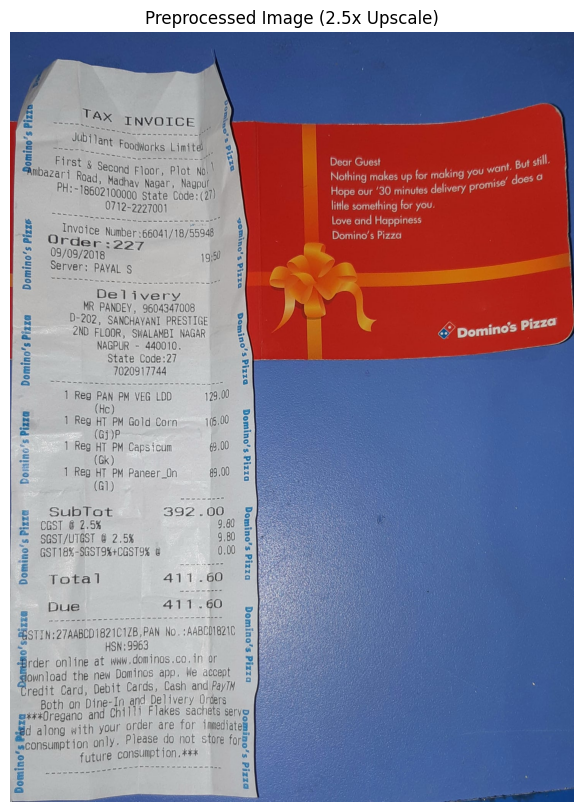

In [3]:
image = preprocess_image(image_path)

plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Preprocessed Image (2.5x Upscale)')
plt.axis('off')
plt.show()


## STEP 2 — Visualize OCR Output

In [4]:
raw_text = run_ocr(image)
lines = [line.strip() for line in raw_text.split('\n') if line.strip()]

print(f"Character Count: {len(raw_text)}")
print(f"Detected Lines: {len(lines)}")
print("-" * 40)
# Show in scrollable output box
display(HTML(f'<div style="height: 300px; overflow-y: scroll; border: 1px solid #ccc; padding: 10px; white-space: pre-wrap;">{raw_text}</div>'))


Character Count: 1076
Detected Lines: 40
----------------------------------------


## STEP 3 — Visualize Line Splitting

In [5]:
price_pattern = re.compile(r'(.+)\s+(\d+[.,]\s*[0-9Oo]{2})$')

html_output = "<div style='background-color: #f7f7f7; padding: 10px; font-family: monospace;'>"
for i, line in enumerate(lines):
    if price_pattern.search(line):
        html_output += f"<div style='color: green;'>[{i}] {line}</div>"
    else:
        html_output += f"<div style='color: black;'>[{i}] {line}</div>"
html_output += "</div>"

display(HTML(html_output))


## STEP 4 & 5 — Validation & Enrichment Execution

In [6]:
extracted_data = extract_bill_data(raw_text)
validated_data = validate_receipt_data(extracted_data)
enriched_data = enrich_receipt_data(validated_data, raw_text, paid_by_user_id)


## STEP 6 — Visualize Category Item Extraction

In [7]:
items = enriched_data.get('items', [])

df_items = pd.DataFrame(items, columns=['name', 'price', 'category'])
display(df_items)

sum_items = sum(item.get('price', 0.0) for item in items)
print(f"\nSum of Item Prices: {sum_items:.2f}")


,name,price,category
0,Reg PAN PM VEG LDD,179.0,Other
1,Reg HI PM Gold Corn,105.0,Other
2,Reg HT PM Capsicum,69.0,Other



Sum of Item Prices: 353.00


## STEP 7 — Visualize Finance & Semantic Blocks

In [8]:
subtotal = enriched_data.get('subtotal')
total = enriched_data.get('total')
taxes = enriched_data.get('taxes', [])
location = enriched_data.get('location')
payment_method = enriched_data.get('payment_method')

print(f"Extracted Location: {location}")
print(f"Payment Method: {payment_method}")
print(f"Paid By User Context: {enriched_data.get('paid_by')}")
print("-" * 30)
print(f"Extracted Subtotal: {subtotal}")
print(f"Extracted Total: {total}")
print(f"\nTaxes:")
df_taxes = pd.DataFrame(taxes, columns=['type', 'amount']) if taxes else pd.DataFrame(columns=['type', 'amount'])
display(df_taxes)


Extracted Location: None
Payment Method: Debit
Paid By User Context: user_987654
------------------------------
Extracted Subtotal: None
Extracted Total: 411.6

Taxes:


,type,amount
0,CGST,9.8
1,SGST,9.8


## STEP 8 — Score Generation Log

In [9]:
sum_taxes = sum(tax.get('amount', 0.0) for tax in taxes)
calc_subtotal_diff = abs(sum_items - subtotal) if subtotal is not None else 0.0
calc_total_diff = abs((subtotal or 0.0) + sum_taxes - total) if total is not None else 0.0

print("Validation Calculations:")
print(f"Item Sum: {sum_items:.2f}")
print(f"Subtotal: {(subtotal or 'N/A')}")
print(f"Difference: {calc_subtotal_diff:.2f}")
print("-" * 30)
print(f"Sum Taxes: {sum_taxes:.2f}")
print(f"Total: {(total or 'N/A')}")
print(f"Total Difference: {calc_total_diff:.2f}")
print("-" * 30)
print(f"Final Confidence Score: {enriched_data.get('confidence_score')}")


Validation Calculations:
Item Sum: 353.00
Subtotal: N/A
Difference: 0.00
------------------------------
Sum Taxes: 19.60
Total: 411.6
Total Difference: 392.00
------------------------------
Final Confidence Score: 0.85


## STEP 9 — Visualize Final Enriched JSON

In [10]:
final_json = format_receipt_json(enriched_data)
print(json.dumps(final_json, indent=4))


{
    "vendor": "! === Kee FoodWorks Limite",
    "location": null,
    "date": null,
    "paid_by": "user_987654",
    "payment_method": "Debit",
    "items": [
        {
            "name": "Reg PAN PM VEG LDD",
            "price": 179.0,
            "category": "Other"
        },
        {
            "name": "Reg HI PM Gold Corn",
            "price": 105.0,
            "category": "Other"
        },
        {
            "name": "Reg HT PM Capsicum",
            "price": 69.0,
            "category": "Other"
        }
    ],
    "subtotal": null,
    "taxes": [
        {
            "type": "CGST",
            "amount": 9.8
        },
        {
            "type": "SGST",
            "amount": 9.8
        }
    ],
    "total": 411.6,
    "confidence_score": 0.85
}


## STEP 10 — Pipeline Recap Summary

In [11]:
comparison_md = f"""| Feature | Value |
|-------|-------|
| Pipeline Stage | Evaluated & Enriched |
| Payer UUID | {enriched_data.get('paid_by')} |
| Mapped Location | {location} |
| Category Parsing | {len(items)} Items Scanned |
| Subtotal | {subtotal} |
| Grand Total | {total} |
| Structural Confidence | {enriched_data.get('confidence_score')} |
"""
display(Markdown(comparison_md))


| Feature | Value |
|-------|-------|
| Pipeline Stage | Evaluated & Enriched |
| Payer UUID | user_987654 |
| Mapped Location | None |
| Category Parsing | 3 Items Scanned |
| Subtotal | None |
| Grand Total | 411.6 |
| Structural Confidence | 0.85 |
